# Problem 1 — Multi-Agent Formation Control: Displaying a Name

**Setup.** $N = 20$ agents live in $\mathbb{R}^2$. A connected communication graph
$\mathcal G(\mathcal V,\mathcal E)$ is generated using the Erdős–Rényi model
$\mathcal G(N,p)$. Starting from random initial positions $x[0]$, the agents use a
**graph-based formation control law** to move — letter by letter — through the
shapes of the letters of the name **PRAJWAL** (this is the name the student
commonly goes by, so no shortening is needed).

**Pipeline**
1. Generate a connected Erdős–Rényi graph on $N=20$ nodes.
2. Draw random initial positions $x[0]\in\mathbb R^2$ for all agents.
3. Design a target point-cloud "formation" for every letter of the name (20 points each).
4. Derive and simulate a provably stable, graph-based formation control law that drives
   the agents from one letter's formation to the next, in sequence.
5. Animate the whole sequence and export it as a video.


In [11]:
import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Video

rng = np.random.default_rng(7)   # fixed seed -> reproducible run
np.set_printoptions(precision=3, suppress=True)


## 1. Connected Erdős–Rényi graph, $N = 20$

$\mathcal G(N,p)$ places an edge between every pair of the $N$ nodes independently
with probability $p$. A random draw of $\mathcal G(N,p)$ need not be connected, so we
resample until we obtain a connected graph (formation control needs the *information*
graph to be connected — otherwise some agents could never learn the relative
positions they need to reach their target).

In [12]:
N = 20
P_EDGE = 0.25

def connected_erdos_renyi(n, p, rng):
    # Resample G(n, p) until it is connected.
    while True:
        seed = int(rng.integers(0, 2**31 - 1))
        G = nx.gnp_random_graph(n, p, seed=seed)
        if nx.is_connected(G):
            return G

G = connected_erdos_renyi(N, P_EDGE, rng)
Lap = nx.laplacian_matrix(G).toarray().astype(float)   # graph Laplacian, L = D - A

print(f"N = {N}, p = {P_EDGE}")
print(f"edges = {G.number_of_edges()}")
print(f"connected = {nx.is_connected(G)}")
print(f"Laplacian eigenvalues (sorted): {np.round(np.sort(np.linalg.eigvalsh(Lap)), 3)}")


N = 20, p = 0.25
edges = 46
connected = True
Laplacian eigenvalues (sorted): [ 0.     1.218  1.47   1.963  2.362  2.742  2.897  3.444  4.048  4.111
  4.49   4.859  5.184  5.822  6.13   6.81   7.366  7.792  8.57  10.721]


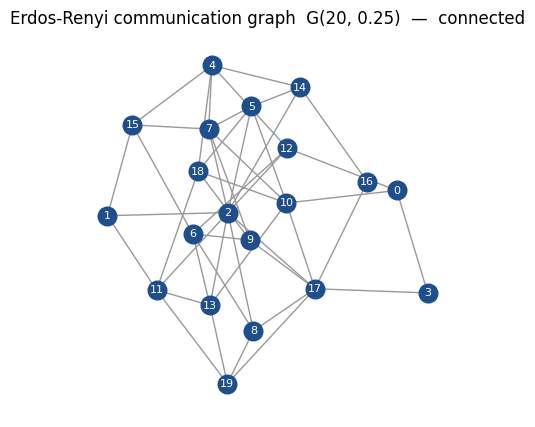

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
pos = nx.spring_layout(G, seed=1)
nx.draw(G, pos, ax=ax, node_size=180, node_color="#1f4e8c", edge_color="0.6", with_labels=True, font_color="white", font_size=8)
ax.set_title(f"Erdos-Renyi communication graph  G({N}, {P_EDGE})  —  connected")
plt.show()


## 2. Random initial positions

Every agent starts at a random position in $\mathbb R^2$, independent of the graph.

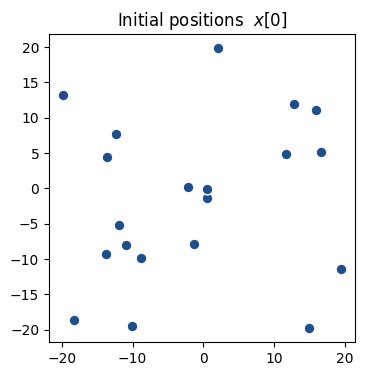

In [14]:
INIT_BOX = 20.0
x0 = rng.uniform(-INIT_BOX, INIT_BOX, size=(N, 2))

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x0[:, 0], x0[:, 1], s=60, c="#1f4e8c", edgecolors="white")
ax.set_title("Initial positions  $x[0]$")
ax.set_aspect("equal")
plt.show()


## 3. Target formation for each letter

Each capital letter is defined as a small set of **strokes** (polylines) on a grid.
To turn a letter into a target formation for exactly $N=20$ agents, we sample $N$
points along the strokes, spaced (approximately) evenly by arc length, with a small
minimum number of points reserved per stroke so that short strokes (e.g. the crossbar
of "A") stay visible. This is the same idea used in drone/robot "sky-writing" formation
displays: the shape is a *point cloud* which the agents occupy, not a continuous line.

In [15]:
FONT = {
    'P': [[(0, 0), (0, 6)],
          [(0, 6), (3, 6), (3, 3), (0, 3)]],
    'R': [[(0, 0), (0, 6)],
          [(0, 6), (3, 6), (3, 3), (0, 3)],
          [(1, 3), (3, 0)]],
    'A': [[(0, 0), (2, 6)],
          [(2, 6), (4, 0)],
          [(2/3, 2), (10/3, 2)]],
    'J': [[(2.5, 6), (2.5, 1.2)],
          [(2.5, 1.2), (2.3, 0.4), (1.5, 0.0), (0.5, 0.5)]],
    'W': [[(0, 6), (1, 0), (2, 4), (3, 0), (4, 6)]],
    'L': [[(0, 6), (0, 0), (3, 0)]],
}

def polyline_length(points):
    pts = np.asarray(points, dtype=float)
    return float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))

def sample_along_polyline(points, n):
    # n points evenly spaced (by arc length) along a polyline.
    pts = np.asarray(points, dtype=float)
    if n <= 0:
        return np.zeros((0, 2))
    seg_vecs = np.diff(pts, axis=0)
    seg_lens = np.linalg.norm(seg_vecs, axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg_lens)])
    total = cum[-1]
    if total == 0:
        return np.tile(pts[0], (n, 1))
    targets = np.linspace(0, total, n)
    out = np.zeros((n, 2))
    for k, t in enumerate(targets):
        idx = np.searchsorted(cum, t, side='right') - 1
        idx = min(max(idx, 0), len(seg_lens) - 1)
        seg_t = 0.0 if seg_lens[idx] == 0 else (t - cum[idx]) / seg_lens[idx]
        out[k] = pts[idx] + seg_t * (pts[idx + 1] - pts[idx])
    return out

def letter_to_points(letter, n_total, min_per_stroke=3):
    # Map a letter to n_total 2D target points, centered at the origin.
    strokes = FONT[letter]
    lens = np.array([polyline_length(s) for s in strokes])
    n_strokes = len(strokes)
    base = min(min_per_stroke, n_total // n_strokes)
    counts = np.full(n_strokes, base, dtype=int)
    remaining = n_total - counts.sum()
    if remaining > 0:
        raw = remaining * lens / lens.sum()
        extra = np.round(raw).astype(int)
        diff = remaining - extra.sum()
        extra[int(np.argmax(lens))] += diff
        counts += extra
    diff = n_total - counts.sum()
    if diff != 0:
        counts[int(np.argmax(lens))] += diff
    pts = np.vstack([sample_along_polyline(s, c) for s, c in zip(strokes, counts)])
    assert len(pts) == n_total
    return pts - pts.mean(axis=0)


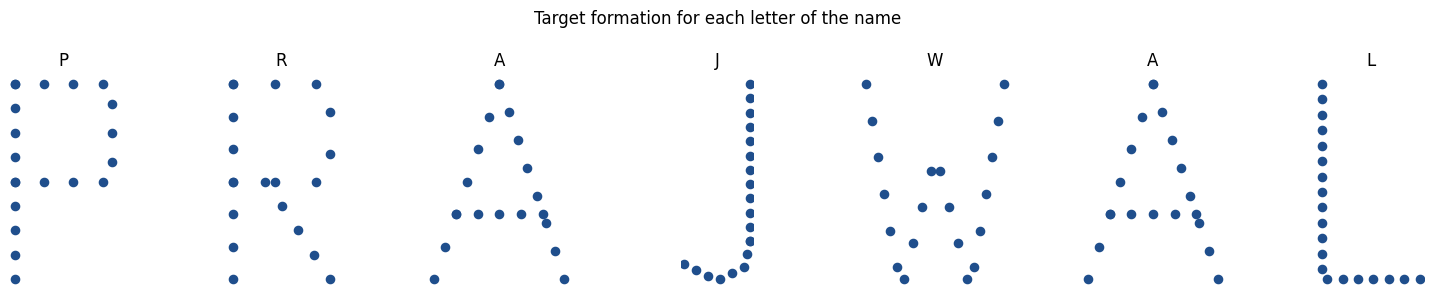

In [16]:
NAME = "PRAJWAL"
SCALE = 3.0
targets = [SCALE * letter_to_points(ch, N) for ch in NAME]

fig, axes = plt.subplots(1, len(NAME), figsize=(2.2 * len(NAME), 3))
for ax, ch, pts in zip(axes, NAME, targets):
    ax.scatter(pts[:, 0], pts[:, 1], s=35, c="#1f4e8c")
    ax.set_title(ch)
    ax.set_aspect("equal")
    ax.axis("off")
plt.suptitle("Target formation for each letter of the name")
plt.tight_layout()
plt.show()


## 4. Formation control law

Let $x_i(t)\in\mathbb R^2$ be agent $i$'s position and $r_i\in\mathbb R^2$ its target
position for the current letter. Each agent combines two pieces of information:

* its own tracking error $x_i-r_i$ (individual navigation to its own goal), and
* the *relative* error to its **graph neighbours**, $(x_i-x_j)-(r_i-r_j)$ for $j\in\mathcal N_i$
  (keeps the agents' relative geometry locked to the target formation through the
  communication graph, exactly as required by the problem).

$$
\dot x_i \;=\; -k_1\,(x_i - r_i) \;-\; k_2\sum_{j\in\mathcal N_i} a_{ij}\Big[(x_i-x_j)-(r_i-r_j)\Big],
\qquad k_1,k_2>0 .
$$

Stacking the $x$- and $y$-coordinates separately and using the graph Laplacian $L$
($(Lx)_i=\sum_j a_{ij}(x_i-x_j)$), the whole network obeys, per coordinate,

$$
\dot x = -\big(k_1 I + k_2 L\big)(x-r) \;=\; -A\,(x - r), \qquad A := k_1 I + k_2 L .
$$

**Why this is guaranteed to converge.** $L$ is symmetric positive semi-definite for
any undirected graph, and it is positive semi-definite with a *simple* zero eigenvalue
(eigenvector $\mathbf 1$) exactly because the graph is connected. Since $k_1>0$,
$A=k_1I+k_2L$ is symmetric **positive definite** — all its eigenvalues satisfy
$\mu_m \ge k_1>0$. With error $e=x-r$, $\dot e = -Ae$ is a linear time-invariant system
with Lyapunov function $V(e)=\tfrac12\|e\|^2$, $\dot V = -e^\top A e \le -k_1\|e\|^2<0$
for $e\neq 0$: **globally exponentially stable**, $\|e(t)\|\le \|e(0)\|e^{-k_1 t}$.
This holds for *any* target $r$, so re-pointing $r$ to the next letter at the end of
each segment keeps the same stability guarantee for the whole sequence.

Diagonalising once, $A = V\,\mathrm{diag}(\mu)\,V^\top$, gives the **closed-form**
solution used below (no numerical ODE integration/error needed):

$$
e(t) = V\,\mathrm{diag}\big(e^{-\mu t}\big)\,V^\top e(0), \qquad x(t) = r + e(t).
$$


In [17]:
K1, K2 = 0.6, 0.8                      # k1: individual-goal gain, k2: neighbour/edge gain
A = K1 * np.eye(N) + K2 * Lap
mu, V = np.linalg.eigh(A)              # A = V diag(mu) V^T   (symmetric -> real eigenbasis)

print("min eigenvalue of A:", mu.min(), " (must be > 0 for guaranteed convergence)")
assert np.all(mu > 1e-9), "A is not positive definite -- graph must be connected and k1>0"


min eigenvalue of A: 0.6000000000000002  (must be > 0 for guaranteed convergence)


## 5. Simulating the full letter sequence

For every letter in turn we solve the closed-form expression above starting from
wherever the previous letter left off, sample it on a time grid, and check the
residual (RMS) error at the end of each segment — it should be tiny, confirming
convergence to the intended letter shape.

In [18]:
T_PER_LETTER = 6.0     # seconds simulated per letter
FPS = 20
FRAMES_PER_LETTER = int(T_PER_LETTER * FPS)
t_grid = np.linspace(0, T_PER_LETTER, FRAMES_PER_LETTER, endpoint=True)

def decay(t):
    return np.exp(-mu * t)

all_frames = []       # (num_frames, N, 2)
letter_of_frame = []
x_cur = x0.copy()

for ch, r in zip(NAME, targets):
    e0 = x_cur - r
    coeff = V.T @ e0
    for t in t_grid:
        e_t = V @ (decay(t)[:, None] * coeff)
        all_frames.append(r + e_t)
        letter_of_frame.append(ch)
    x_cur = all_frames[-1].copy()

all_frames = np.array(all_frames)
print("total animation frames:", len(all_frames))

print(f"{'letter':>8} {'rms error at end of segment':>30}")
for i, ch in enumerate(NAME):
    final_frame = all_frames[i * FRAMES_PER_LETTER + FRAMES_PER_LETTER - 1]
    err = np.linalg.norm(final_frame - targets[i]) / np.sqrt(N)
    print(f"{ch:>8} {err:30.5f}")


total animation frames: 840
  letter    rms error at end of segment
       P                        0.05896
       R                        0.00161
       A                        0.00006
       J                        0.00025
       W                        0.00014
       A                        0.00017
       L                        0.00024


## 6. Animation

The plot shows the 20 agents (blue dots) and the fixed communication graph edges
(light grey lines, following the agents as they move) as they morph, letter by
letter, through **P → R → A → J → W → A → L**.

In [19]:
edges = list(G.edges())

fig, ax = plt.subplots(figsize=(6, 6))
all_xy = all_frames.reshape(-1, 2)
pad = 3
ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)
ax.set_aspect('equal')
ax.axis('off')

edge_lines = [ax.plot([], [], '-', color='0.75', lw=0.8, zorder=1)[0] for _ in edges]
scat = ax.scatter([], [], s=60, c='#1f4e8c', zorder=3, edgecolors='white', linewidths=0.5)
title = ax.text(0.5, 1.02, '', transform=ax.transAxes, ha='center', va='bottom',
                 fontsize=16, fontweight='bold')

def init():
    scat.set_offsets(np.empty((0, 2)))
    return [scat, title, *edge_lines]

def update(frame_idx):
    pts = all_frames[frame_idx]
    scat.set_offsets(pts)
    for line, (i, j) in zip(edge_lines, edges):
        line.set_data([pts[i, 0], pts[j, 0]], [pts[i, 1], pts[j, 1]])
    t_in_letter = (frame_idx % FRAMES_PER_LETTER) / FPS
    title.set_text(f"Agents forming letter: {letter_of_frame[frame_idx]}   (t = {t_in_letter:4.1f}s)")
    return [scat, title, *edge_lines]

ani = animation.FuncAnimation(fig, update, frames=len(all_frames), init_func=init, blit=True)

writer = animation.FFMpegWriter(fps=FPS, bitrate=1800)
ani.save('name_formation.mp4', writer=writer, dpi=130)
plt.close(fig)
print("Saved name_formation.mp4")


Saved name_formation.mp4


In [20]:
Video('name_formation.mp4', embed=False, width=480)
